In [7]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image

# Load pre-trained Mask R-CNN (V1)
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
# model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(pretrained=True)  # alternative V2

# Set to evaluation mode
model.eval()

# COCO class labels
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
   'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [8]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    transform = transforms.ToTensor()
    return transform(image)

# Load images
image1 = load_image("images/Street.jpeg")
image2 = load_image("images/Wildlife.jpeg")

# Run inference
with torch.no_grad():
    predictions1 = model([image1])[0]
    predictions2 = model([image2])[0]

In [9]:
def get_detected_classes(predictions, threshold=0.5):
    labels = predictions['labels']
    scores = predictions['scores']
    filtered = [(COCO_INSTANCE_CATEGORY_NAMES[label], label.item())
                for label, score in zip(labels, scores) if score > threshold]
    return filtered

classes1 = get_detected_classes(predictions1)
classes2 = get_detected_classes(predictions2)

print("Street.jpeg detected classes:", classes1)
print("Wildlife.jpeg detected classes:", classes2)

Street.jpeg detected classes: [('person', 1), ('person', 1), ('horse', 18), ('horse', 18), ('horse', 18), ('horse', 18), ('handbag', 27), ('horse', 18), ('person', 1), ('person', 1)]
Wildlife.jpeg detected classes: [('backpack', 25), ('backpack', 25), ('bear', 22), ('bear', 22), ('backpack', 25), ('bear', 22), ('cat', 16), ('bear', 22), ('cat', 16), ('cat', 16), ('cat', 16), ('cat', 16)]


In [20]:
import cv2
import numpy as np

def draw_predictions(image_tensor, predictions, threshold=0.5):
    image = image_tensor.mul(255).byte().numpy().transpose(1, 2, 0).copy()
    boxes = predictions['boxes']
    labels = predictions['labels']
    scores = predictions['scores']
    masks = predictions['masks']

    for i in range(len(boxes)):
        if scores[i] > threshold:
            box = boxes[i].detach().numpy().astype(int)
            label = COCO_INSTANCE_CATEGORY_NAMES[labels[i]]
            score = scores[i].item()

            # Draw box
            cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            cv2.putText(image, f"{label}: {score:.2f}", (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

            # Draw mask
            mask = masks[i, 0].detach().numpy()
            mask = (mask > 0.5).astype(np.uint8)
            colored_mask = np.zeros_like(image)
            colored_mask[:, :, 1] = mask * 255  # green mask
            image = cv2.addWeighted(image, 1, colored_mask, 0.5, 0)

    return image

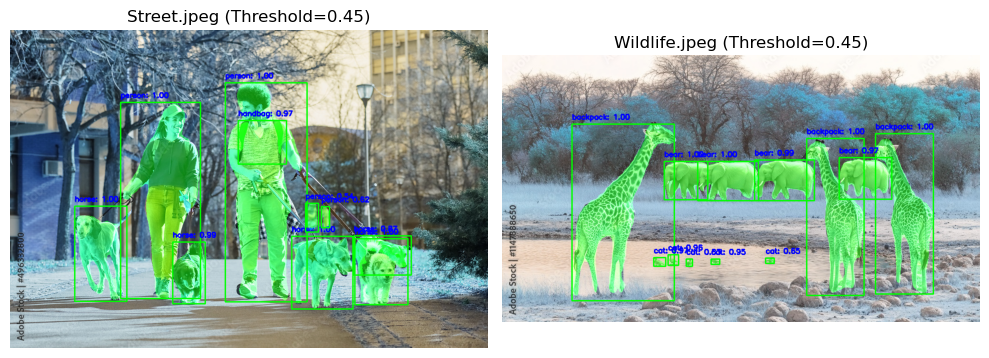

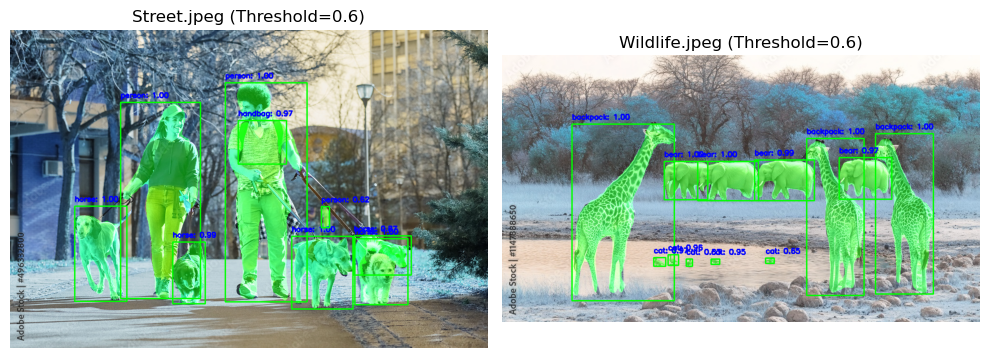

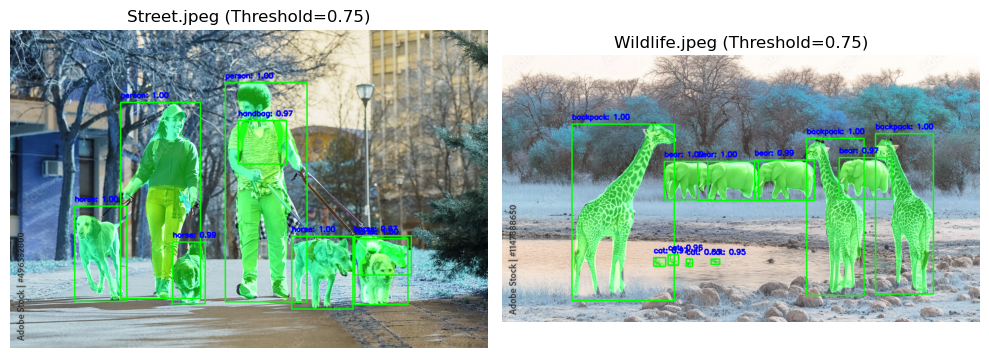

In [21]:
import matplotlib.pyplot as plt

for thresh in [0.45, 0.60, 0.75]:
    result1 = draw_predictions(image1, predictions1, threshold=thresh)
    result2 = draw_predictions(image2, predictions2, threshold=thresh)

    # Convert BGR (OpenCV) to RGB for Matplotlib
    result1_rgb = cv2.cvtColor(result1, cv2.COLOR_BGR2RGB)
    result2_rgb = cv2.cvtColor(result2, cv2.COLOR_BGR2RGB)

    # Show Street image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(result1_rgb)
    plt.title(f"Street.jpeg (Threshold={thresh})")
    plt.axis('off')

    # Show Wildlife image
    plt.subplot(1, 2, 2)
    plt.imshow(result2_rgb)
    plt.title(f"Wildlife.jpeg (Threshold={thresh})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()